1. Load & Clean the Data

In [ ]:
### ***Importing Libraries***
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
import re as re
from datetime import datetime
from functools import reduce
import seaborn as sns

In [ ]:
### ***Importing csv file***

In [ ]:
df=pd.read_csv('/content/customer_signups.csv')

In [ ]:
df.head(5)

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaN,Instagram,NaN,basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,02-01-24,LinkedIn,West,basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,03-01-24,Google,North,PREMIUM,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,04-01-24,YouTube,NaN,Pro,No,40,Male
4,CUST00004,NaN,matthew4@mailhub.org,05-01-24,LinkedIn,West,Premium,No,25,Other


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       298 non-null    object
 1   name              291 non-null    object
 2   email             266 non-null    object
 3   signup_date       298 non-null    object
 4   source            291 non-null    object
 5   region            270 non-null    object
 6   plan_selected     292 non-null    object
 7   marketing_opt_in  290 non-null    object
 8   age               288 non-null    object
 9   gender            292 non-null    object
dtypes: object(10)
memory usage: 23.6+ KB


In [ ]:
# Identify column structure
print("Column Structure:")
print("Columns:", df.columns.tolist())
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\n")

Column Structure:
Columns: ['customer_id', 'name', 'email', 'signup_date', 'source', 'region', 'plan_selected', 'marketing_opt_in', 'age', 'gender']
Number of rows: 300
Number of columns: 10




In [ ]:
# Identify data types
print(df.dtypes)

customer_id         object
name                object
email               object
signup_date         object
source              object
region              object
plan_selected       object
marketing_opt_in    object
age                 object
gender              object
dtype: object


In [ ]:
# Identify missing values
df.isnull().sum()

,0
customer_id,2
name,9
email,34
signup_date,2
source,9
region,30
plan_selected,8
marketing_opt_in,10
age,12
gender,8


1.2 Convert signup_date to datetime

In [ ]:
# convert sign_up to datetime #
df['signup_date'] = pd.to_datetime(df['signup_date'],errors='coerce',dayfirst=True)
df.head(5)

/tmp/ipython-input-3609380463.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['signup_date'] = pd.to_datetime(df['signup_date'],


,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaT,Instagram,NaN,basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,2024-01-02,LinkedIn,West,basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,2024-01-03,Google,North,PREMIUM,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,2024-01-04,YouTube,NaN,Pro,No,40,Male
4,CUST00004,NaN,matthew4@mailhub.org,2024-01-05,LinkedIn,West,Premium,No,25,Other


1.3 STANDARDISE INCOSINSTENT TEXT VALUES

In [ ]:
#   Marketing Opt_in
df['marketing_opt_in'] = df['marketing_opt_in'].str.title()
opt_in_mapping = {
    'Yes': 'Yes', 'Y': 'Yes', 'True': 'Yes',
    'No': 'No', 'N': 'No', 'False': 'No',
    'Nil': '', 'None': '', 'Nan': '', '': 'No'
}
df['marketing_opt_in'] = df['marketing_opt_in'].replace(opt_in_mapping)

In [ ]:
#   plan_selected
plan_mapping = {
    'Basic': 'Basic',
    'Pro': 'Pro',
    'Premium': 'Premium',
    'Prem': 'Premium',
    'Unknownplan': '',
    'Nan': '',
    '': '',
    'None': ''
}
df['plan_selected'] = df['plan_selected'].replace(plan_mapping)

# Ensure only valid plans remain
valid_plans = ['Basic', 'Pro', 'Premium']
df['plan_selected'] = df['plan_selected'].apply(lambda x: x if x in valid_plans else 'Basic')

In [ ]:
#  Gender
gender_mapping = {
    'Male': 'Male', 'male': 'Male', 'MALE': 'Male',
    'Female': 'Female', 'female': 'Female', 'FEMALE': 'Female',
    'Non-Binary': 'Non-Binary', 'Non Binary': 'Non-Binary',
    'Other': 'Other',
    '123': '', 'Thirty': '', 'Unknown': '',
    'Nan': '', '': ''
}
df['gender'] = df['gender'].replace(gender_mapping)

In [ ]:
# Remove "??" and leave the cell blank
df['source'] = df['source'].replace("??", "")

In [ ]:
# Convert email to lowercase
df['email'] = df['email'].str.lower()

In [ ]:
# Replace any remaining 'Nan' strings from object columns
df = df.replace({'Nan': np.nan, 'None': np.nan, '': np.nan})

1.4 Remove duplicate rows based on customer_id

In [ ]:
# Remove duplicate rows based on customer_id (keep the first one)

df = df.drop_duplicates(subset='customer_id', keep='first')

In [ ]:
df.shape

(299, 10)

1.5 Handle missing values (e.g., region, email, age)

In [ ]:
# create a placeholder if missing email is missing

df['email'] = df['email'].fillna('no-email@unknown.com')
df.fillna("Unknown")

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,no-email@unknown.com,Unknown,Instagram,Unknown,Basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,2024-01-02 00:00:00,LinkedIn,West,Basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,2024-01-03 00:00:00,Google,North,Basic,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,2024-01-04 00:00:00,YouTube,Unknown,Pro,No,40,Male
4,CUST00004,Unknown,matthew4@mailhub.org,2024-01-05 00:00:00,LinkedIn,West,Premium,No,25,Other
...,...,...,...,...,...,...,...,...,...,...
295,CUST00295,Gary Smith,gary95@example.com,2024-10-22 00:00:00,Google,West,Basic,Yes,40,Unknown
296,CUST00296,Anthony Roberts,anthony96@mailhub.org,2024-10-23 00:00:00,Google,Central,Basic,Yes,25,Female
297,CUST00297,Timothy Mclaughlin,no-email@unknown.com,2024-10-24 00:00:00,Instagram,West,Basic,Yes,60,Unknown
298,CUST00298,Justin Mcintyre,justin98@mailhub.org,2024-10-25 00:00:00,YouTube,South,Premium,No,53,Male


**2. Data Quality Summary**

In [ ]:
# Count missing values per column
missing = df.isnull().sum()

print(missing)

customer_id          1
name                 9
email                0
signup_date          6
source              15
region              30
plan_selected        0
marketing_opt_in    11
age                 12
gender              14
dtype: int64


In [ ]:
# percentage of missing values per column
total_rows = df.shape[0]
missing_percent = (df.isnull().sum() / total_rows * 100).round(2)
print(missing_percent)

customer_id          0.33
name                 3.01
email                0.00
signup_date          2.01
source               5.02
region              10.03
plan_selected        0.00
marketing_opt_in     3.68
age                  4.01
gender               4.68
dtype: float64


In [ ]:
# Identify duplicated customer_id rows (excluding the first occurrence)
dupe_mask = df.duplicated(subset=['customer_id'], keep='first')

# Count duplicates per customer_id
dupe_counts = df.loc[dupe_mask, 'customer_id'].value_counts().sort_index()

dupe_counts


,count
customer_id,


**3. Summary Outputs** (Using Pandas Aggregations)

In [ ]:
# 3.1 Fix age column (convert to numeric)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
# 3.2. Sign-ups per week
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
signups_per_week = df.groupby(df['signup_date'].dt.to_period('W')).size()

print(signups_per_week)

signup_date
2024-01-01/2024-01-07    6
2024-01-08/2024-01-14    7
2024-01-15/2024-01-21    7
2024-01-22/2024-01-28    7
2024-01-29/2024-02-04    8
2024-02-05/2024-02-11    7
2024-02-12/2024-02-18    7
2024-02-19/2024-02-25    7
2024-02-26/2024-03-03    7
2024-03-04/2024-03-10    7
2024-03-11/2024-03-17    7
2024-03-18/2024-03-24    6
2024-03-25/2024-03-31    6
2024-04-01/2024-04-07    7
2024-04-08/2024-04-14    7
2024-04-15/2024-04-21    7
2024-04-22/2024-04-28    7
2024-04-29/2024-05-05    6
2024-05-06/2024-05-12    7
2024-05-13/2024-05-19    7
2024-05-20/2024-05-26    7
2024-05-27/2024-06-02    7
2024-06-03/2024-06-09    6
2024-06-10/2024-06-16    7
2024-06-17/2024-06-23    7
2024-06-24/2024-06-30    7
2024-07-01/2024-07-07    7
2024-07-08/2024-07-14    7
2024-07-15/2024-07-21    6
2024-07-22/2024-07-28    7
2024-07-29/2024-08-04    7
2024-08-05/2024-08-11    6
2024-08-12/2024-08-18    7
2024-08-19/2024-08-25    7
2024-08-26/2024-09-01    7
2024-09-02/2024-09-08    7
2024-09-09/2024-

In [ ]:
# 3.4 Sign-ups by source, region, plan_selected
signups_by_source = df['source'].value_counts()
signups_by_region = df['region'].value_counts()
signups_by_plan = df['plan_selected'].value_counts()

print(signups_by_source)

source
YouTube      58
Google       50
Referral     49
Instagram    48
Facebook     40
LinkedIn     39
Name: count, dtype: int64


In [ ]:
# Replace any remaining non-standard values
df['marketing_opt_in'] = df['marketing_opt_in'].apply(lambda x: x if x in ['Yes', 'No'] else 'Unknown')

# Create cross-tabulation: marketing_opt_in vs gender
print("Marketing Opt-In Counts by Gender".center(60))
print("="*60)

count_table = pd.crosstab(
    df['gender'],
    df['marketing_opt_in'],
    margins=True,
    margins_name="Total"
)

# Reorder columns for clarity
count_table = count_table[['Yes', 'No', 'Unknown', 'Total']]

print(count_table)

             Marketing Opt-In Counts by Gender              
marketing_opt_in  Yes   No  Unknown  Total
gender                                    
Female             44   47        1     92
Male               38   50        4     92
Non-Binary         19   20        3     42
Other              24   32        3     59
Total             125  149       11    285


In [ ]:
# 4. Age summary
age_summary = {
    "min": df['age'].min(),
    "max": df['age'].max(),
    "mean": df['age'].mean(),
    "median": df['age'].median(),
    "null_count": df['age'].isna().sum()
}

print(age_summary)

{'min': 21.0, 'max': 206.0, 'mean': np.float64(36.175), 'median': 34.0, 'null_count': np.int64(19)}


In [ ]:
# Drop the email column
df = df.drop(columns=['email'], errors='ignore')


In [ ]:
df.to_csv('Cleaned_customer_sign_up.csv')

In [ ]:
# Define columns to check for missing values
columns_to_check = ['name', 'signup_date', 'source', 'region', 'age', 'gender', 'marketing_opt_in']

# Count missing values per column, grouped by region
print("Missing or incomplete data count by region:\n")
print("-" * 60)

missing_by_region = df.groupby('region')[columns_to_check].apply(lambda x: x.isnull().sum())

# Also include rows where region itself is missing
missing_region_count = df['region'].isnull().sum()
if missing_region_count > 0:
    print(f"Rows with missing region: {missing_region_count}\n")

# Transpose for better readability
missing_summary = missing_by_region.T
missing_summary = missing_summary.fillna(0).astype(int)

# Add total row
missing_summary.loc['TOTAL'] = missing_summary.sum()

print(missing_summary.to_string())

Missing or incomplete data count by region:

------------------------------------------------------------
Rows with missing region: 30

region            Central  East  North  South  West
name                    0     2      3      1     3
signup_date             1     0      1      2     1
source                  1     1      4      3     4
region                  0     0      0      0     0
age                     3     6      3      2     3
gender                  1     5      1      3     4
marketing_opt_in        0     0      0      0     0
TOTAL                   6    14     12     11    15


**EDA**

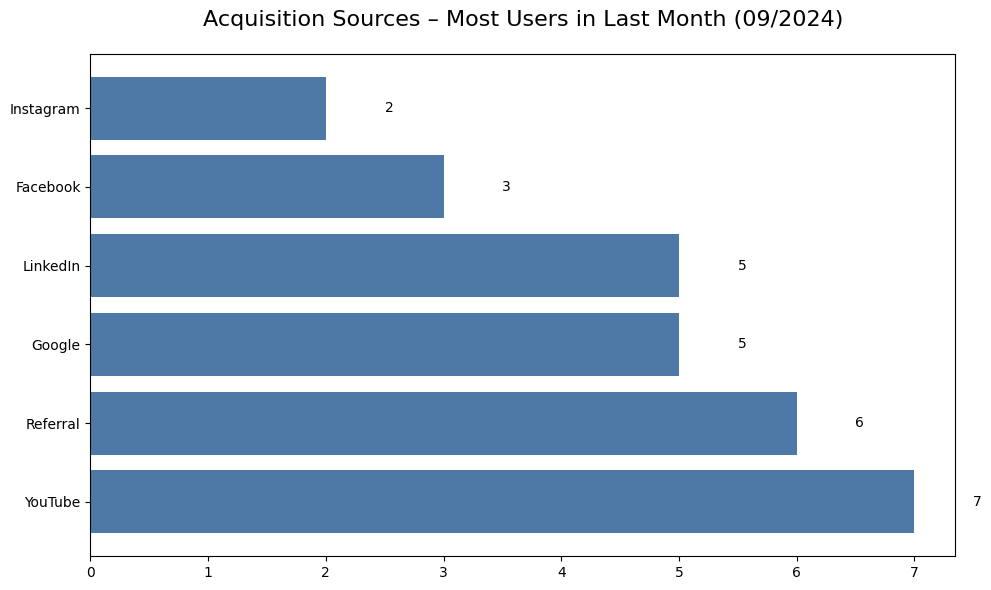

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# --- 3. Convert signup_date to proper datetime (ignore rows without a date) ---
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

# --- 4. Determine "last month" based on the latest date in the dataframe ---
today = df['signup_date'].max()                     # Use the latest signup date in the data

# Handle case where df['signup_date'] might be entirely NaT (no valid dates)
if pd.isna(today):
    print("No valid signup dates found in the DataFrame.")
else:
    last_month_year = today.year if today.month > 1 else today.year - 1
    last_month_month = today.month - 1 if today.month > 1 else 12

    # Filter for last month
    df_last_month = df[
        (df['signup_date'].dt.year == last_month_year) &
        (df['signup_date'].dt.month == last_month_month)
    ]

    # --- 5. Count users per source (ignoring blank sources) ---
    source_counts = df_last_month['source'].value_counts(dropna=True)

    # --- 6. Plot a nice horizontal bar chart ---
    if not source_counts.empty:
        plt.figure(figsize=(10, 6))
        bars = plt.barh(source_counts.index, source_counts.values, color='#4e79a7')

        # Highlight the top source
        top_source_name = source_counts.idxmax()
        top_source_position = source_counts.index.get_loc(top_source_name)


        plt.title(f'Acquisition Sources – Most Users in Last Month '
                  f'({last_month_month:02d}/{last_month_year})', fontsize=16, pad=20)


        # Add value labels on the bars
        for i, (source, count) in enumerate(source_counts.items()):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No sign-ups found for {last_month_month:02d}/{last_month_year} to plot.")


/tmp/ipython-input-2980886026.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['age_group'] = df_clean['age'].apply(lambda x: 'Older (≥32)' if x >= age_threshold else 'Younger (<32)')


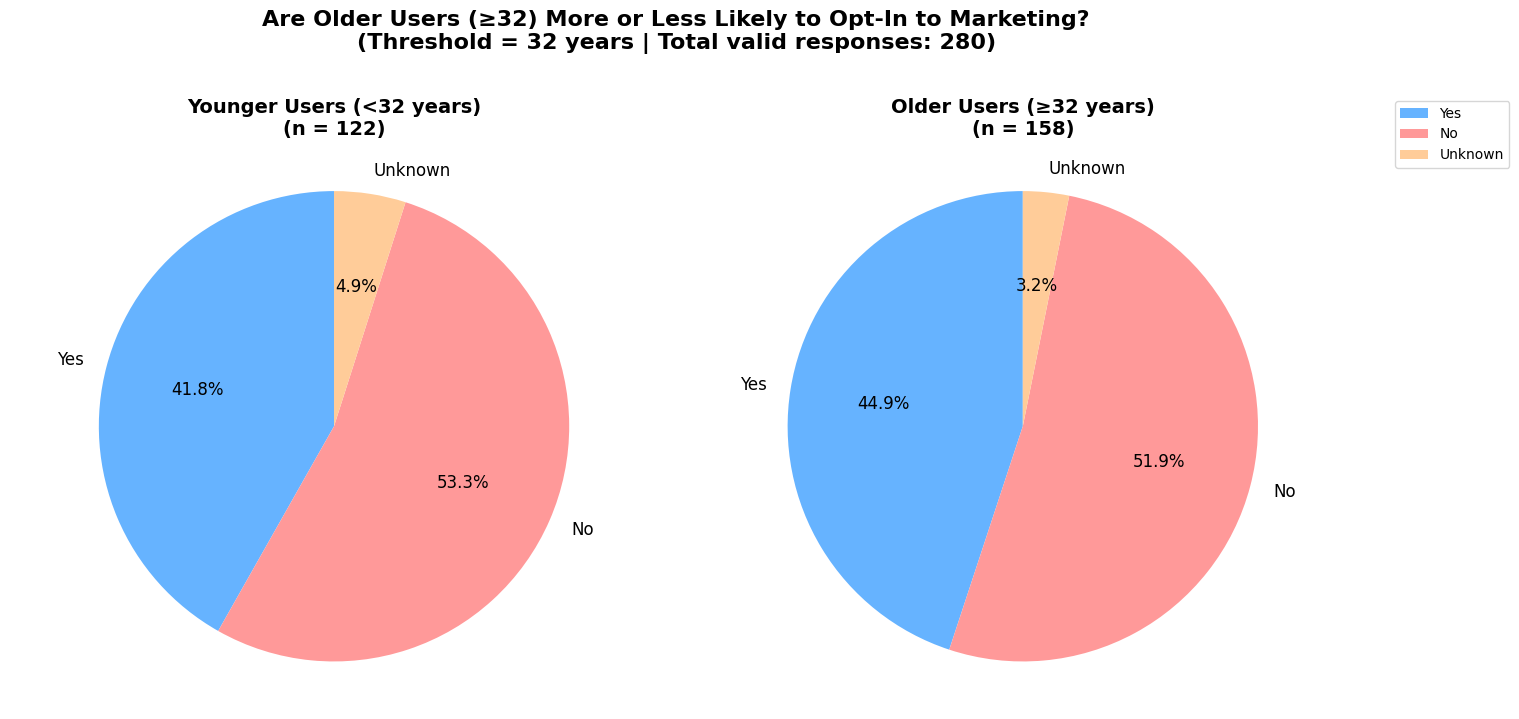

In [ ]:
# Clean column names (in case of extra unnamed column)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Remove unnamed columns
df.columns = ['customer_id', 'name', 'signup_date', 'source', 'region',
              'plan_selected', 'marketing_opt_in', 'age', 'gender']

# Clean and convert age
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop rows where age or marketing_opt_in is missing (for this analysis)
df_clean = df.dropna(subset=['age', 'marketing_opt_in'])

# Define age threshold
age_threshold = 32

# Create age group
df_clean['age_group'] = df_clean['age'].apply(lambda x: 'Older (≥32)' if x >= age_threshold else 'Younger (<32)')

# Count marketing opt-in by age group
optin_counts = df_clean.groupby(['age_group', 'marketing_opt_in']).size().unstack(fill_value=0)

# Ensure both 'Yes' and 'No' columns exist
for col in ['Yes', 'No', 'Unknown']:
    if col not in optin_counts.columns:
        optin_counts[col] = 0

# Reorder columns
optin_counts = optin_counts[['Yes', 'No', 'Unknown']]

# Calculate percentages
optin_percent = optin_counts.div(optin_counts.sum(axis=1), axis=0) * 100

# Plotting: Two pie charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Colors
colors = ['#66b3ff', '#ff9999', '#ffcc99']  # Yes = blue, No = red, Unknown = orange

# Pie chart 1: Younger users
ax1.pie(optin_counts.loc['Younger (<32)'], labels=optin_counts.columns, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 12})
ax1.set_title(f'Younger Users (<32 years)\n(n = {optin_counts.loc["Younger (<32)"].sum()})', fontsize=14, fontweight='bold')

# Pie chart 2: Older users
ax2.pie(optin_counts.loc['Older (≥32)'], labels=optin_counts.columns, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 12})
ax2.set_title(f'Older Users (≥32 years)\n(n = {optin_counts.loc["Older (≥32)"].sum()})', fontsize=14, fontweight='bold')

# Add a main title
plt.suptitle('Are Older Users (≥32) More or Less Likely to Opt-In to Marketing?\n'
             f'(Threshold = {age_threshold} years | Total valid responses: {len(df_clean)})',
             fontsize=16, fontweight='bold', y=1.02)

# Equal aspect ratio
ax1.axis('equal')
ax2.axis('equal')

# Add legend
fig.legend(['Yes', 'No', 'Unknown'], loc='upper right', bbox_to_anchor=(1.1, 0.9))

plt.tight_layout()
plt.show()



plan_selected      Basic    Premium        Pro
age_group                                     
Older (≥32)    60.759494  22.784810  16.455696
Younger (<32)  65.573770  14.754098  19.672131


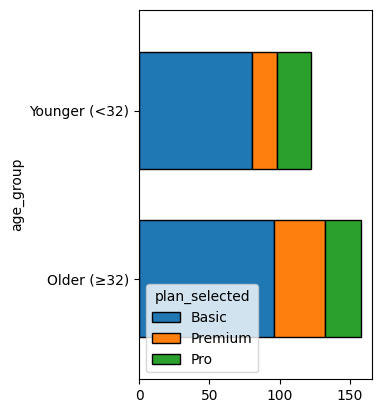

In [ ]:
# Selection by Age Group (Stacked Bar Chart) ===
ax2 = plt.subplot(1, 2, 2)

# Create cross-tab: age group vs plan
ct = pd.crosstab(df_clean['age_group'], df_clean['plan_selected'])
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100  # Convert to percentage

print(ct_percentage)

# Plot stacked bar
ct.plot(kind='barh', stacked=True, ax=ax2, width=0.7, edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()